# 01 · El problema predictivo: de la decisión a Y = f(X) + ε

**Edición docente · 8 de octubre de 2026 · Modelos Predictivos en Negocios**

**Unidad 1 · Semanas 1–2 · RA1 (CE 1.1–1.4) · 120–150 minutos.**
Traducirás decisiones de negocio en problemas predictivos, distinguirás error reducible e irreducible, compararás contra una línea base y detectarás una fuga de información antes de que contamine un modelo.

**Cómo trabajar:** ejecuta desde la primera celda. Antes de mover un control, escribe qué esperas que ocurra;
después compara y justifica la diferencia. Los casos son docentes: FinCordillera, QuillayMarket y PulpaLenga son
empresas ficticias con datos simulados del repositorio; las simulaciones adicionales se identifican como tales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten leer los
resultados sin ejecutar. Cada función interactiva también puede llamarse directamente con argumentos.

[Guía maestra](../guia_maestra_mpn.html) · [Manual científico](../material_propio/MPN_manual_cientifico.pdf) ·
[Cobertura curricular](../COBERTURA.md)

In [1]:
from pathlib import Path
import sys
import warnings
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "03_Modelos_Predictivos_Negocios"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
import mpn_recursos as mr
from mpn_recursos import pregunta, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .18, "font.size": 10})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format",
              lambda v: f"{v:,.0f}" if abs(v) >= 1e4 or float(v).is_integer() else f"{v:,.3f}")
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · semilla {SEMILLA}")

Python 3.12.13 · pandas 3.0.6 · semilla 2026


<a id="diagnostico-python"></a>
## Diagnóstico breve: Python y scikit-learn

Antes de modelar: leer una tabla, distinguir filas/columnas, seleccionar X/y y reconocer fit/predict. `fit` aprende con entrenamiento; `predict` aplica lo aprendido a otras filas. Actividad: explicar por qué `fit` con toda la tabla antes de reservar prueba cambia el resultado que se pretende evaluar. Este bloque se puede omitir en clase si el diagnóstico demuestra dominio.

In [2]:
from sklearn.linear_model import LinearRegression
mini=pd.DataFrame({'inversion':[1,2,3,4],'ventas':[12,14,16,18]})
X_mini=mini[['inversion']];y_mini=mini['ventas']
modelo_mini=LinearRegression().fit(X_mini.iloc[:3],y_mini.iloc[:3])
pred_mini=modelo_mini.predict(X_mini.iloc[3:])
display(mini);print('Filas X/y:',X_mini.shape,y_mini.shape,'Predicción reservada:',pred_mini)
assert np.allclose(pred_mini,[18])  # Relación artificial exacta; no refleja error de negocio.


,inversion,ventas
0,1,12
1,2,14
2,3,16
3,4,18


Filas X/y: (4, 1) (4,) Predicción reservada: [18.]


<a id="estructura"></a>

## Estructura de un modelo predictivo

Un modelo predictivo supone que el resultado de negocio $Y$ se relaciona con información disponible $X$ mediante
$Y = f(X) + \varepsilon$, con $E[\varepsilon \mid X] = 0$ y $\operatorname{Var}(\varepsilon)=\sigma^2$. El analista no conoce $f$:
la aproxima con un estimador $\hat f$ aprendido de datos históricos. Para una observación nueva en $x$,

$$E\big[(Y-\hat f(x))^2\big] = \underbrace{\big(f(x)-E[\hat f(x)]\big)^2}_{\text{sesgo}^2} + \underbrace{\operatorname{Var}\big(\hat f(x)\big)}_{\text{varianza}} + \underbrace{\sigma^2}_{\text{irreducible}}.$$

El sesgo y la varianza son **error reducible**; $\sigma^2$ no: ni siquiera la $f$ verdadera lo elimina. En negocio,
$\varepsilon$ reúne lo que no se observa o no se puede anticipar: decisiones de la competencia, clima, ánimo del cliente.

La simulación usa un mecanismo conocido —demanda semanal que depende de forma curva del precio— para poder
comparar el ajuste con la verdad. Cambia el ruido $\sigma$ y el grado del polinomio: observa el error en entrenamiento
y en 2.000 observaciones nuevas.

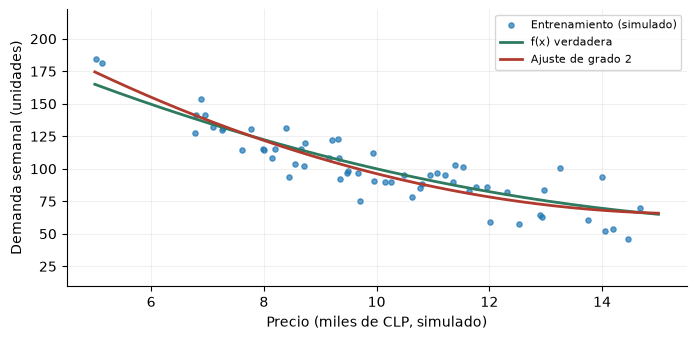

,valor
ECM entrenamiento,144.300
ECM observaciones nuevas,159.800
ECM usando f verdadera,144.900
σ² del proceso,144


interactive(children=(FloatSlider(value=12.0, description='σ', max=40.0, min=1.0, step=1.0), IntSlider(value=2…

In [3]:
PRECIO_MIN, PRECIO_MAX = 5, 15
def f_verdadera(precio):
    return 260 - 22 * precio + 0.6 * precio ** 2      # mecanismo conocido solo porque es simulado

def generar(n, sigma, semilla):
    g = np.random.default_rng(semilla)
    precio = g.uniform(PRECIO_MIN, PRECIO_MAX, n)
    return precio, f_verdadera(precio) + g.normal(0, sigma, n)

def explorar_ruido(sigma=12.0, grado=2):
    x, y = generar(60, sigma, SEMILLA)            # muestra de entrenamiento
    xn, yn = generar(2000, sigma, SEMILLA + 1)    # observaciones nuevas del mismo proceso
    z = lambda v: (v - 10) / 5                    # centrar y escalar estabiliza el ajuste polinomial
    coef = np.polyfit(z(x), y, grado)
    ecm_entrenamiento = np.mean((np.polyval(coef, z(x)) - y) ** 2)
    ecm_nuevo = np.mean((np.polyval(coef, z(xn)) - yn) ** 2)
    ecm_oraculo = np.mean((f_verdadera(xn) - yn) ** 2)
    grilla = np.linspace(PRECIO_MIN, PRECIO_MAX, 200)
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.scatter(x, y, s=14, alpha=.7, label="Entrenamiento (simulado)")
    ax.plot(grilla, f_verdadera(grilla), color="#2d7a5f", lw=2, label="f(x) verdadera")
    ax.plot(grilla, np.polyval(coef, z(grilla)), color="#b03a2e", lw=2, label=f"Ajuste de grado {grado}")
    ax.set(xlabel="Precio (miles de CLP, simulado)", ylabel="Demanda semanal (unidades)",
           ylim=(np.percentile(y, 1) - 40, np.percentile(y, 99) + 40))
    ax.legend(fontsize=8)
    plt.show()
    resultado = pd.Series({"ECM entrenamiento": ecm_entrenamiento, "ECM observaciones nuevas": ecm_nuevo,
                           "ECM usando f verdadera": ecm_oraculo, "σ² del proceso": sigma ** 2})
    display(resultado.round(1).to_frame("valor"))
    return resultado

base_ruido = explorar_ruido()
widgets.interact(explorar_ruido,
                 sigma=widgets.FloatSlider(value=12, min=1, max=40, step=1, description="σ"),
                 grado=widgets.IntSlider(value=2, min=1, max=10, description="grado"));

**Lectura.** Con grado 1 la recta no sigue la curvatura: el error en datos nuevos queda por encima de $\sigma^2$ por
**sesgo** (subajuste). Con grado alto el error de entrenamiento baja, pero el de observaciones nuevas sube por
**varianza** (sobreajuste). Ninguna configuración baja sostenidamente de $\sigma^2$: es el piso del problema.
Una promesa de «predicción exacta» ignora ese piso.

<a id="tipos"></a>

## Tipo de problema, unidad de predicción y momento de decisión

Formular bien el problema decide más que el algoritmo. Para cada caso se declara la variable $Y$, la **unidad**
(qué representa una fila), el **momento** en que se predice y la **decisión** que cambia con la predicción. La
métrica guía se elige por el costo de los errores, no por costumbre.

In [4]:
casos = pd.DataFrame([
    ["FinCordillera · retención", "abandono en el trimestre (0/1)", "Clasificación", "cliente", "cierre de mes", "a quién ofrecer retención", "costo esperado, AP"],
    ["FinCordillera · fraude", "fraude (0/1)", "Clasificación de evento raro", "transacción", "autorización, en línea", "bloquear o verificar", "precisión a recall fijo"],
    ["QuillayMarket · demanda", "unidades vendidas", "Regresión", "categoría-mes", "planificación de compras", "cuánto stock comprar", "MAE y sesgo"],
    ["PulpaLenga · calidad", "lote defectuoso (0/1)", "Clasificación", "lote", "antes de despachar", "inspeccionar o liberar", "costo esperado"],
    ["PulpaLenga · energía", "MWh por lote", "Regresión", "lote", "programación semanal", "energía a contratar", "RMSE y MAPE"],
    ["TalentoMas · rotación", "renuncia en 6 meses (0/1)", "Clasificación", "colaborador", "evaluación semestral", "plan de retención", "recall y revisión por grupo"],
    ["CentroSalud · camas", "camas ocupadas por día", "Regresión / serie de tiempo", "especialidad-día", "turnos semanales", "dotación de personal", "MAE y cobertura de intervalos"],
    ["QuillayMarket · segmentos", "no existe Y observada", "No supervisado (no predictivo)", "cliente", "diseño de campaña", "oferta por grupo", "estabilidad e interpretación"],
], columns=["Caso", "Y", "Tipo", "Unidad", "Momento", "Decisión", "Métrica guía"])
display(casos)

,Caso,Y,Tipo,Unidad,Momento,Decisión,Métrica guía
0,FinCordillera · retención,abandono en el trimestre (0/1),Clasificación,cliente,cierre de mes,a quién ofrecer retención,"costo esperado, AP"
1,FinCordillera · fraude,fraude (0/1),Clasificación de evento raro,transacción,"autorización, en línea",bloquear o verificar,precisión a recall fijo
2,QuillayMarket · demanda,unidades vendidas,Regresión,categoría-mes,planificación de compras,cuánto stock comprar,MAE y sesgo
3,PulpaLenga · calidad,lote defectuoso (0/1),Clasificación,lote,antes de despachar,inspeccionar o liberar,costo esperado
4,PulpaLenga · energía,MWh por lote,Regresión,lote,programación semanal,energía a contratar,RMSE y MAPE
5,TalentoMas · rotación,renuncia en 6 meses (0/1),Clasificación,colaborador,evaluación semestral,plan de retención,recall y revisión por grupo
6,CentroSalud · camas,camas ocupadas por día,Regresión / serie de tiempo,especialidad-día,turnos semanales,dotación de personal,MAE y cobertura de intervalos
7,QuillayMarket · segmentos,no existe Y observada,No supervisado (no predictivo),cliente,diseño de campaña,oferta por grupo,estabilidad e interpretación


**Tres reglas de formulación.** (1) $Y$ debe medirse después de la predicción con una definición estable.
(2) Toda variable de $X$ tiene que existir **en el momento de decidir**. (3) La unidad de predicción define las filas
del dataset; mezclar unidades (cliente y transacción) produce conteos y métricas incoherentes.

<a id="linea-base"></a>

## Línea base: el primer modelo que hay que superar

Una línea base es la regla más simple razonable: la clase mayoritaria en clasificación o el promedio histórico en
regresión. Un modelo solo aporta valor si mejora la línea base **en la métrica que importa** y en datos que no usó
para aprender. Se compara en un conjunto reservado.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, roc_auc_score, accuracy_score
from sklearn.pipeline import Pipeline

banco = mr.fincordillera_clientes()
demanda = mr.quillaymarket_demanda()
tasa_abandono = banco["churn"].mean()

d_ent, d_pru = train_test_split(demanda, test_size=.25, random_state=SEMILLA)
mae_media = mean_absolute_error(d_pru["ventas_unidades"], np.full(len(d_pru), d_ent["ventas_unidades"].mean()))
simple = LinearRegression().fit(d_ent[["promocion_activa"]], d_ent["ventas_unidades"])
mae_promocion = mean_absolute_error(d_pru["ventas_unidades"], simple.predict(d_pru[["promocion_activa"]]))

lineas_base = pd.DataFrame({
    "regla": ["Clase mayoritaria (nadie abandona)", "Promedio de ventas", "Regresión solo con promoción"],
    "caso": ["FinCordillera", "QuillayMarket", "QuillayMarket"],
    "métrica": ["accuracy", "MAE en prueba (unidades)", "MAE en prueba (unidades)"],
    "valor": [1 - tasa_abandono, mae_media, mae_promocion]})
display(lineas_base.round(3))
print(f"Tasa de abandono observada: {tasa_abandono:.1%}. Una accuracy de 72% se logra sin modelo.")

,regla,caso,métrica,valor
0,Clase mayoritaria (nadie abandona),FinCordillera,accuracy,0.720
1,Promedio de ventas,QuillayMarket,MAE en prueba (unidades),41.385
2,Regresión solo con promoción,QuillayMarket,MAE en prueba (unidades),40.876


Tasa de abandono observada: 28.0%. Una accuracy de 72% se logra sin modelo.


**Lectura.** En FinCordillera, declarar que nadie abandona logra una accuracy cercana a 72% y no detecta ningún caso:
por eso accuracy no sirve como métrica guía cuando la decisión trata del evento minoritario. En QuillayMarket, agregar
solo la promoción reduce el error respecto del promedio: es una mejora medible contra una referencia explícita.

<a id="fuga"></a>

## Fuga de información: cuando el modelo «ve» el futuro

Una **fuga** (*data leakage*) ocurre cuando el modelo usa información que no estará disponible al predecir. El
resultado típico es un desempeño espectacular en validación y un fracaso en operación. Se simula una variable que
el sistema registra **después** de que el cliente decide irse: «solicitud de cierre registrada». La variable es
artificial y se agrega solo para el ejercicio.

In [6]:
X = banco.drop(columns=["cliente_id", "churn"])
y = banco["churn"]
numericas = X.select_dtypes("number").columns.tolist()
categoricas = ["region"]
Xe, Xv, Xt, ye, yv, yt = mr.particion_tres(X, y)

def ajustar(X_ent, X_val, columnas_num):
    modelo = Pipeline([("preparar", mr.preprocesador(columnas_num, categoricas)),
                       ("modelo", LogisticRegression(max_iter=2000))]).fit(X_ent, ye)
    return modelo, roc_auc_score(yv, modelo.predict_proba(X_val)[:, 1])

modelo_honesto, auc_honesto = ajustar(Xe, Xv, numericas)

g = np.random.default_rng(SEMILLA + 7)
def agregar_variable_posterior(X_, y_):
    salida = X_.copy()
    salida["solicitud_cierre_registrada"] = np.where(y_ == 1, g.random(len(y_)) < .85, g.random(len(y_)) < .03).astype(int)
    return salida

_, auc_fuga = ajustar(agregar_variable_posterior(Xe, ye), agregar_variable_posterior(Xv, yv),
                      numericas + ["solicitud_cierre_registrada"])
display(pd.Series({"AUC validación · variables disponibles al decidir": auc_honesto,
                   "AUC validación · con variable posterior al evento": auc_fuga}).round(3).to_frame("valor"))

,valor
AUC validación · variables disponibles al decidir,0.715
AUC validación · con variable posterior al evento,0.957


**Lectura.** El AUC con la variable posterior es mucho mayor, pero es ilusorio: al momento de predecir esa columna
no existe o vale cero para todos. **Prueba de disponibilidad:** para cada variable pregunta «¿cuándo se registra y
quién la registra?». Otras fugas frecuentes: totales calculados con el período futuro, identificadores que codifican
el resultado y estadísticas de preparación calculadas con todos los datos (ver notebook 02).

<a id="tecnicas"></a>

## Técnicas principales: principio, fortalezas y límites (CE 1.1)

| Técnica | Principio | Fortalezas | Limitaciones | Ejemplo de negocio |
|---|---|---|---|---|
| Regresión lineal | Combinación lineal de variables que minimiza errores al cuadrado | Interpretable, rápida, base de comparación | Supone forma lineal y es sensible a valores extremos | Demanda según precio y promoción |
| Regresión logística | Modela el logaritmo de las chances de un evento | Probabilidades e interpretación por razones de chances | Fronteras lineales salvo transformaciones | Abandono de clientes, mora |
| Árbol de decisión | Divide el espacio con reglas «si–entonces» | Reglas legibles, capta no linealidades | Inestable y propenso al sobreajuste | Reglas de inspección de lotes |
| Bosque aleatorio | Promedia muchos árboles con muestras y variables al azar | Buen desempeño con poco ajuste | Menos interpretable; probabilidades a veces mal calibradas | Detección de defectos |
| KNN | Predice con los casos más parecidos | Simple, sin forma funcional | Depende de la escala y de la dimensión | Recomendaciones por similitud |
| Redes neuronales | Composición de transformaciones no lineales | Patrones complejos con muchos datos | Datos, cómputo y explicabilidad exigentes | Imágenes de calidad, texto |
| Series de tiempo | Usa la dinámica temporal: tendencia y estacionalidad | Respeta el orden del tiempo | Requiere historia y supone cierta estabilidad | Demanda mensual (notebook 07) |

Ninguna técnica gana siempre: se elige por el tipo de $Y$, el volumen de datos, la necesidad de explicar cada
decisión y el costo de equivocarse.

<a id="red-neuronal"></a>
## Red neuronal mínima: composición y límites (CE1.1)

Dos entradas escaladas pasan por una capa ReLU y una salida sigmoide. Los pesos de este ejemplo se fijan a mano: **no se entrenó ni validó un modelo bancario**. En una red entrenada, gradientes ajustan pesos para reducir una pérdida supervisada; la regularización y validación controlan sobreajuste. La ventaja es combinar señales de forma no lineal; los costos son datos, cómputo, estabilidad e interpretación. Compare con logística/árbol antes de complejizar.

Actividad: con entradas cero, calcule h=(0,.1), puntaje=−.58 y p≈.359. Después explique por qué ese número entre cero y uno no es automáticamente una probabilidad calibrada ni una recomendación de retención.

In [7]:
def explorar_red(reclamos=0.,antiguedad=0.):
    x=np.array([reclamos,antiguedad]);W1=np.array([[1.,-.5],[-.3,.8]])
    h=np.maximum(0,W1@x+np.array([-.2,.1]));z=np.array([1.5,-.8])@h-.5;p=1/(1+np.exp(-z))
    display(pd.Series({'h1':h[0],'h2':h[1],'puntaje':z,'salida_sigmoide':p}))
    return p
assert np.isclose(explorar_red(0,0),1/(1+np.exp(.58)))
widgets.interact(explorar_red,reclamos=widgets.FloatSlider(value=0,min=-2,max=2,step=.1),antiguedad=widgets.FloatSlider(value=0,min=-2,max=2,step=.1));


h1                     0
h2                 0.100
puntaje           -0.580
salida_sigmoide    0.359
dtype: float64

interactive(children=(FloatSlider(value=0.0, description='reclamos', max=2.0, min=-2.0), FloatSlider(value=0.0…

<a id="comunicar"></a>

## Explicar sin tecnicismos (CE 1.3–1.4)

Una buena explicación conecta la predicción con la decisión, declara el horizonte y el nivel de incertidumbre y
evita jerga. Se calcula qué ocurre en validación si se contacta al 20% de clientes con mayor riesgo estimado.

In [8]:
riesgo_val = modelo_honesto.predict_proba(Xv)[:, 1]
corte_20 = np.quantile(riesgo_val, .80)
contactados = riesgo_val >= corte_20
tasa_contactados = yv[contactados].mean()
captura = yv[contactados].sum() / yv.sum()
mensaje = (f"Si contactamos al 20% de clientes con mayor riesgo estimado, alrededor de {tasa_contactados:.0%} de ellos "
           f"abandonaría sin intervención, frente a {yv.mean():.0%} en la cartera completa. Ese grupo concentra "
           f"cerca de {captura:.0%} de los abandonos del período de validación. Son estimaciones sobre {len(yv)} clientes "
           "simulados: antes de una campaña real se debe confirmar con datos recientes y un piloto controlado.")
display(Markdown("> " + mensaje))

> Si contactamos al 20% de clientes con mayor riesgo estimado, alrededor de 55% de ellos abandonaría sin intervención, frente a 28% en la cartera completa. Ese grupo concentra cerca de 40% de los abandonos del período de validación. Son estimaciones sobre 190 clientes simulados: antes de una campaña real se debe confirmar con datos recientes y un piloto controlado.

### Ejercicios resueltos

1. **Formular.** «Queremos vender más» no es un problema predictivo. Una formulación posible: predecir las unidades
   por categoría para el próximo mes ($Y$ numérica, unidad categoría-mes) para decidir la compra de inventario.
   **Respuesta orientativa:** declara $Y$, unidad, horizonte, decisión y métrica (MAE en unidades).
2. **Clasificar el problema.** ¿Predecir el monto de una transacción fraudulenta es clasificación? No: el monto es
   numérico (regresión); *si* la transacción es fraude es clasificación. Un mismo negocio puede requerir ambos.
3. **Detectar fuga.** En un modelo de mora se usa «días de atraso al cierre del año». Si la predicción se hace en
   enero para todo el año, la variable incorpora el resultado: debe reemplazarse por atrasos **anteriores** a enero.
4. **Error irreducible.** Si $\sigma=12$, ¿puede un modelo tener ECM de 50 en datos nuevos de forma sostenida?
   No: el piso esperado es $\sigma^2 = 144$. Un valor menor en una muestra pequeña es variabilidad muestral o fuga.

In [9]:
auto_01 = pregunta("Un modelo de abandono usa la variable «fecha de cierre de cuenta». ¿Qué ocurre?",
                   ["Mejora el modelo y debe conservarse", "Introduce información posterior al evento: es una fuga",
                    "Solo exige estandarizar la variable"], 1,
                   "La fecha de cierre se conoce después del abandono. En operación no existe al momento de decidir.")
assert auc_fuga > auc_honesto + .05
assert abs((1 - tasa_abandono) - .72) < .01
assert mae_promocion < mae_media
assert base_ruido["ECM observaciones nuevas"] > .8 * base_ruido["σ² del proceso"]
print("Comprobaciones del laboratorio 01: OK")

Comprobaciones del laboratorio 01: OK


### Referencias

[James, Witten, Hastie, Tibshirani y Taylor: ISLP](https://www.statlearning.com/) (capítulo 2, sesgo y varianza) ·
[scikit-learn: errores frecuentes y fuga de información](https://scikit-learn.org/stable/common_pitfalls.html).
Los casos y simulaciones de esta práctica son docentes y se documentan para reproducción.